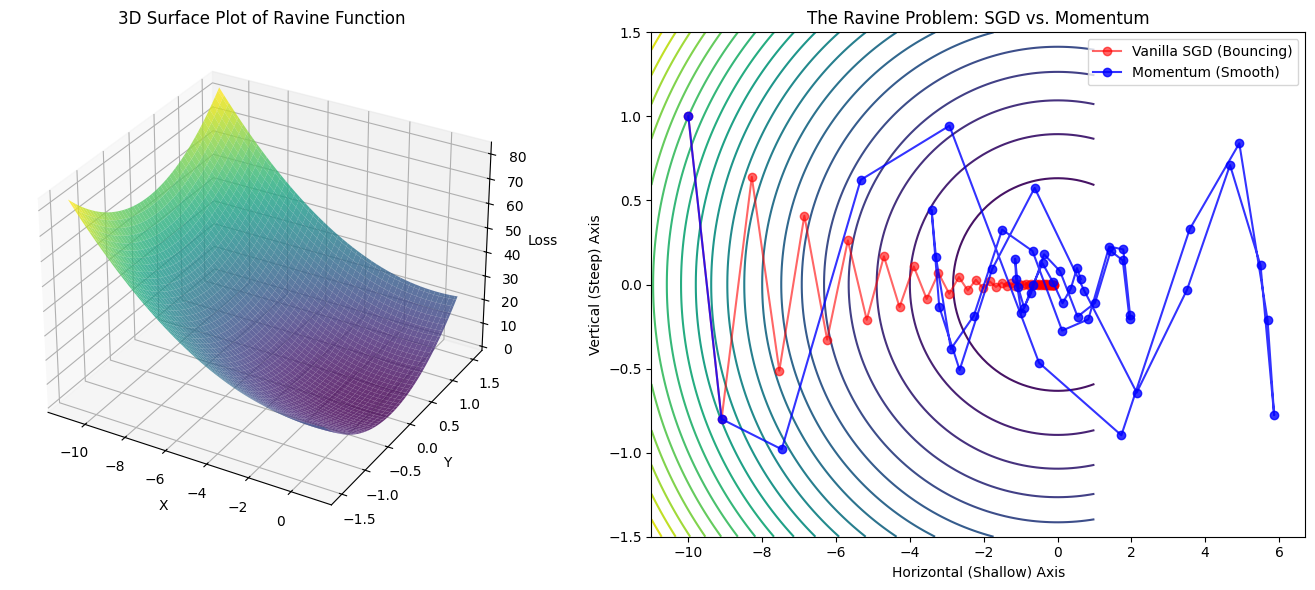

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Define the Ravine Function: f(x, y) = 0.5*x^2 + 10*y^2
# The y-direction (10) is much steeper than the x-direction (0.5)
def loss_function(x, y):
    return 0.5 * x**2 + 10 * y**2

def gradients(x, y):
    df_dx = x
    df_dy = 20 * y
    return np.array([df_dx, df_dy])


# 2. Optimization Parameters
learning_rate = 0.09
momentum_coeff = 0.9
iterations = 50
start_pos = np.array([-10.0, 1.0])

# 3. Vanilla SGD Implementation
def run_sgd(start_pos, lr, iters):
    path = [start_pos]
    curr_pos = start_pos.copy()
    for _ in range(iters):
        grad = gradients(curr_pos[0], curr_pos[1])
        curr_pos -= lr * grad
        path.append(curr_pos.copy())
    return np.array(path)

# 4. Momentum SGD Implementation
def run_momentum(start_pos, lr, gamma, iters):
    path = [start_pos]
    curr_pos = start_pos.copy()
    velocity = np.zeros_like(start_pos)
    for _ in range(iters):
        grad = gradients(curr_pos[0], curr_pos[1])
        # v = gamma * v + lr * grad
        velocity = gamma * velocity + lr * grad
        curr_pos -= velocity
        path.append(curr_pos.copy())
    return np.array(path)

# Run simulations
path_sgd = run_sgd(start_pos, learning_rate, iterations)
path_mom = run_momentum(start_pos, learning_rate, momentum_coeff, iterations)

# 5. Visualization
x = np.linspace(-11, 1, 100)
y = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x, y)
Z = loss_function(X, Y)

# 3D Surface Plot
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Loss')
ax.set_title('3D Surface Plot of Ravine Function')

# 2D Contour Plot with Paths
ax2 = fig.add_subplot(122)
ax2.contour(X, Y, Z, levels=20, cmap='viridis')
ax2.plot(path_sgd[:, 0], path_sgd[:, 1], 'ro-', label='Vanilla SGD (Bouncing)', alpha=0.6)
ax2.plot(path_mom[:, 0], path_mom[:, 1], 'bo-', label='Momentum (Smooth)', alpha=0.8)
ax2.set_title("The Ravine Problem: SGD vs. Momentum")
ax2.set_xlabel("Horizontal (Shallow) Axis")
ax2.set_ylabel("Vertical (Steep) Axis")
ax2.legend()

plt.tight_layout()
plt.show()
